# Dual Domain Adaptive ViT

- A cross-domain feature alignment module
- Enables interaction between steel and sugar representations
- Projects features from each domain into a shared latent space  
- Applies attention-based mechanisms to capture complementary structural and textural relationships. 

*Why?*

- Facilitates knowledge transfer across tasks; each branch benefits from patterns learned in the other domain
- Doesn't compromise domain-specific specialization
- Useful in industrial settings where different inspection tasks share underlying visual characteristics, 
- Improves generalization
- Enhances robustness to variations
- Reduces need for large domain-specific datasets by leveraging shared feature understanding

## Modules

In [530]:
import os
from pathlib import Path

In [531]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': 'Times New Roman'})
plt.rcParams.update({'font.size': 14})

In [532]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [533]:
import segmentation_models_pytorch as smp
import timm

## Configs

### Directory

In [534]:
BASE_DIR = Path().resolve()
ROOT_DIR = (BASE_DIR.parent).parent

### Models

In [535]:
STEEL_MODEL_PATH = os.path.join(ROOT_DIR,  "Models", "Final", "steel.pth")
SUGAR_MODEL_PATH = os.path.join(ROOT_DIR, "Models", "Final", "sugar.pth")

# Print both paths neatly, check if they exist
print(f"Steel model path: {STEEL_MODEL_PATH}")
print(f"Sugar model path: {SUGAR_MODEL_PATH}")
print(f"Steel model exists: {os.path.exists(STEEL_MODEL_PATH)}")
print(f"Sugar model exists: {os.path.exists(SUGAR_MODEL_PATH)}")

Steel model path: E:\Studies\MIT\8\Project\Models\Final\steel.pth
Sugar model path: E:\Studies\MIT\8\Project\Models\Final\sugar.pth
Steel model exists: True
Sugar model exists: True


### Test Images

In [536]:
STEEL_IMAGE_PATH = os.path.join(ROOT_DIR, "Datasets", "steel-defect-detection", "test_images", "00a0b7730.jpg")
SUGAR_IMAGE_PATH = os.path.join(ROOT_DIR, "Datasets", "sugar-quality-inspection", "test_images", "metastable", "1.jpg")

# Print both paths neatly, check if they exist
print(f"Steel image path: {STEEL_IMAGE_PATH}")
print(f"Sugar image path: {SUGAR_IMAGE_PATH}")
print(f"Steel image exists: {os.path.exists(STEEL_IMAGE_PATH)}")
print(f"Sugar image exists: {os.path.exists(SUGAR_IMAGE_PATH)}")

Steel image path: E:\Studies\MIT\8\Project\Datasets\steel-defect-detection\test_images\00a0b7730.jpg
Sugar image path: E:\Studies\MIT\8\Project\Datasets\sugar-quality-inspection\test_images\metastable\1.jpg
Steel image exists: True
Sugar image exists: True


### Device

In [537]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Classes

In [538]:
NUM_STEEL_CLASSES = 4
NUM_SUGAR_CLASSES = 4

## Models

### Steel Model - mit_b4

In [539]:
steel_model = smp.Unet(
    encoder_name="mit_b4",
    encoder_weights=None,   # set to None as trained weights are loaded
    in_channels=3,
    classes=NUM_STEEL_CLASSES
)

steel_model.load_state_dict(torch.load(STEEL_MODEL_PATH, map_location=device))
steel_model.to(device)
steel_model.eval()

Unet(
  (encoder): MixVisionTransformerEncoder(
    (patch_embed1): OverlapPatchEmbed(
      (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed2): OverlapPatchEmbed(
      (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed3): OverlapPatchEmbed(
      (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed4): OverlapPatchEmbed(
      (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (block1): Sequential(
      (0): Block(
        (norm1): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (q): Linear(in_features=64

### Sugar Model - Swin Transformer

In [540]:
sugar_model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,   # avoid overwriting trained weights
    num_classes=NUM_SUGAR_CLASSES
)

sugar_model.load_state_dict(torch.load(SUGAR_MODEL_PATH, map_location=device))
sugar_model.to(device)
sugar_model.eval()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

### Sanity Check

In [541]:
x = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    out = sugar_model(x)

print("Sugar model OK:", out.shape)

Sugar model OK: torch.Size([1, 4])


In [542]:
x = torch.randn(1, 3, 256, 256).to(device)

with torch.no_grad():
    out = steel_model(x)

print("Steel model OK:", out.shape)

Steel model OK: torch.Size([1, 4, 256, 256])


## DDA-ViT

### Backbones Wrappers

- Steel: use encoder of UNet --> mit_b4 backbone
- Sugar: use Swin's forward_features()
- Ensures meaningful feature extraction

#### Steel Backbone

In [543]:
class SteelBackbone(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.encoder = model.encoder  # SegFormer encoder

    def forward(self, x):
        features = self.encoder(x)  # list of feature maps
        return features[-1]         # deepest feature map

#### Sugar Backbone

In [544]:
class SugarBackbone(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        features = self.model.forward_features(x)  # supported by timm
        return features

### Feature Projection

- Aligns feature dimensions
- Converts to token space for attention

In [545]:
class FeatureProjector(nn.Module):
    def __init__(self, in_channels, embed_dim):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

### Cross Domain Feature Aligner

- Enables interaction between domains
- Transfers structural + texture knowledge

In [546]:
class CrossDomainAttention(nn.Module):
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)

    def forward(self, Fs, Fq):
        out, _ = self.attn(Fs, Fq, Fq)
        return out

### DDA-ViT Core

- Uses real feature paths from the trained models
- Handles segmentation + classification mismatch
- Performs cross-domain attention

In [547]:
class DDAViT(nn.Module):
    def __init__(self, steel_model, sugar_model, embed_dim=256,
                 num_defect_classes=4, num_quality_classes=4):
        super().__init__()

        self.steel = SteelBackbone(steel_model)
        self.sugar = SugarBackbone(sugar_model)

        self.proj_s = nn.Conv2d(512, embed_dim, kernel_size=1)
        self.proj_q = nn.Linear(768, embed_dim)

        self.cross_attn = CrossDomainAttention(embed_dim)

        self.seg_head = nn.Conv2d(embed_dim, num_defect_classes, kernel_size=1)
        self.sugar_head = nn.Linear(embed_dim, num_quality_classes)

    def forward(self, x_steel=None, x_sugar=None):

        Fs_map, Fq = None, None

        if x_steel is not None:
            Fs_map = self.steel(x_steel)                        # (B, C, H, W)
            Fs_map = self.proj_s(Fs_map)                        # (B, d, H, W)

            B, d, H, W = Fs_map.shape
            Fs = Fs_map.flatten(2).transpose(1, 2)              # (B, N, d)

        if x_sugar is not None:
            Fq = self.sugar(x_sugar)

            if Fq.dim() == 4:                                   # (B, H, W, C)
                B, H, W, C = Fq.shape
                Fq = Fq.view(B, H * W, C)

            if Fq.dim() == 3:                                   # (B, N, C)
                Fq = self.proj_q(Fq)
                Fq = Fq.mean(dim=1, keepdim=True)

            elif Fq.dim() == 2:                                 # (B, C)
                Fq = self.proj_q(Fq)
                Fq = Fq.unsqueeze(1)

            else:
                raise ValueError(f"Unexpected sugar feature shape: {Fq.shape}")

        if Fs_map is not None and Fq is not None:
            Fs_fused = self.cross_attn(Fs, Fq)  # (B, N, d)

            Fs_map = Fs_fused.transpose(1, 2).reshape(B, d, H, W)

        if x_steel is not None:
            # seg_out = self.seg_head(Fs_map)  # (B, 4, H, W)
            # return seg_out
            seg_out = self.seg_head(Fs_map)

            # Upsample to input size
            seg_out = F.interpolate(
                seg_out,
                size=x_steel.shape[2:],  # (H, W)
                mode="bilinear",
                align_corners=False
            )

            return seg_out

        if x_sugar is not None:
            F_out = Fq.mean(dim=1)  # (B, d)
            return self.sugar_head(F_out)

        raise ValueError("Provide x_steel or x_sugar")

### Freezing Backbones

- Keeps pretrained knowledge intact
- Trains only fusion layers

In [548]:
def freeze_model(model):
    for p in model.parameters():
        p.requires_grad = False

freeze_model(steel_model)
freeze_model(sugar_model)

## Implementation Setup

### Initialise DDA-ViT

In [549]:
model = DDAViT(steel_model, sugar_model)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DDAViT(
  (steel): SteelBackbone(
    (encoder): MixVisionTransformerEncoder(
      (patch_embed1): OverlapPatchEmbed(
        (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (patch_embed2): OverlapPatchEmbed(
        (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (patch_embed3): OverlapPatchEmbed(
        (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
      )
      (patch_embed4): OverlapPatchEmbed(
        (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      )
      (block1): Sequential(
        (0): Block(
          (norm1): LayerNorm((64,), eps=1e-06, elementwise_affine=T

### Optimiser

In [550]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

### Sanity Check

In [551]:
x_steel = torch.randn(2, 3, 256, 256).to(device)
x_sugar = torch.randn(2, 3, 224, 224).to(device)

out_s = model(x_steel=x_steel)
out_q = model(x_sugar=x_sugar)

print("Steel output:", out_s.shape)
print("Sugar output:", out_q.shape)

Steel output: torch.Size([2, 4, 256, 256])
Sugar output: torch.Size([2, 4])


## Image and Prediction Setup

### Load Image Function

In [552]:
def load_image(path, size):
    img = cv2.imread(path)

    if img is None:
        raise ValueError(f"Failed to load image at path: {path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    scale = size / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)

    resized = cv2.resize(img, (new_w, new_h))

    # Pad to square
    pad_img = np.zeros((size, size, 3), dtype=np.uint8)
    pad_img[:new_h, :new_w] = resized

    img_norm = pad_img.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img_norm).permute(2, 0, 1).unsqueeze(0)

    return img, tensor, (new_h, new_w)

### Steel Defect Segmentation

#### Inference - Sliding Window

- Splits full-width image into patches
- Runs DDA-ViT on each patch
- Reconstructs full segmentation map
- Supports overlap via averaging

In [553]:
def sliding_window_inference(model, image, patch_size=256, stride=256):
    model.eval()

    H, W, _ = image.shape

    full_mask = np.zeros((4, H, W))
    count_map = np.zeros((H, W))

    for x in range(0, W - patch_size + 1, stride):

        patch = image[:, x:x+patch_size]
        patch_tensor = torch.from_numpy(patch).permute(2, 0, 1).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(x_steel=patch_tensor)
            probs = torch.sigmoid(output)[0].cpu().numpy()

        full_mask[:, :, x:x+patch_size] += probs
        count_map[:, x:x+patch_size] += 1

    # Normalize overlapping regions
    full_mask /= np.maximum(count_map, 1e-6)

    return full_mask

#### Prediction Function

In [554]:
def predict_steel(model, image_path):
    model.eval()

    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Failed to load image: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.copy()

    img = img.astype(np.float32) / 255.0

    # Ensure height = 256
    img = cv2.resize(img, (img.shape[1], 256))

    # -------------------------
    # SLIDING WINDOW
    # -------------------------
    probs = sliding_window_inference(model, img)

    mask = np.argmax(probs, axis=0)

    # Resize back to original
    mask = cv2.resize(mask, (original.shape[1], original.shape[0]), interpolation=cv2.INTER_NEAREST)

    # -------------------------
    # VISUALIZATION
    # -------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="jet")
    plt.title("Sliding Window Segmentation")
    plt.axis("off")

    plt.show()

    unique, counts = np.unique(mask, return_counts=True)
    total = mask.size

    print("\nDefect Summary:")
    for u, c in zip(unique, counts):
        if u == 0:
            continue
        print(f"- Class {u}: {(c/total)*100:.2f}% area")

### Sugar Quality Inspection

In [555]:
def predict_sugar(model, image_path, class_names):
    model.eval()

    _, img, _ = load_image(image_path, size=224)
    img = img.to(device)

    with torch.no_grad():
        output = model(x_sugar=img)
        probs = torch.softmax(output, dim=1)[0].cpu().numpy()

    pred = np.argmax(probs)

    print("\nPrediction:", class_names[pred])
    print("\nProbabilities:")
    for i, p in enumerate(probs):
        print(f"{class_names[i]}: {p:.4f}")

### Class Names

In [556]:
steel_classes = ["1", "2", "3", "4"]

sugar_classes = ["unsaturated", "metastable", "intermediate", "labile"]

## Prediction

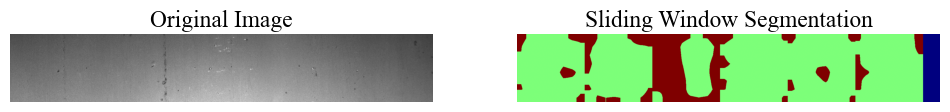


Defect Summary:
- Class 1: 77.58% area
- Class 2: 18.42% area

Prediction: metastable

Probabilities:
unsaturated: 0.2391
metastable: 0.3070
intermediate: 0.2710
labile: 0.1829


In [557]:
predict_steel(model, STEEL_IMAGE_PATH)
predict_sugar(model, SUGAR_IMAGE_PATH, sugar_classes)